# Exploratory SNA, chapter 5


This notebook provides a Python transcription of the analyses that are presented in Chapter 5 "Affiliations" of the book: Wouter de Nooy / Andrej Mrvar / Vladimir Batagelj, _Exploratory Social Network Analysis with Pajek_, Third edition, Cambridge: Cambridge University Press, 2018. 


It reuses the same data about directors and co-directors in different firms stemming from an "historical example: the corporate interlocks in Scotland in the beginning of the twentieth century (1904–5)". 

Data import demands some workarounds (see below)


[10 Mai 2025] At the moment the notebook covers only up to par. 5.4 included.


In [162]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches

import seaborn as sns

import numpy as np
import scipy.stats as stats
import pprint as pprint

In [2]:
# https://networkx.org/documentation/stable/install.html
import networkx as nx

from networkx.algorithms import bipartite

#### https://ipycytoscape.readthedocs.io/en/latest/installing.html
# import ipycytoscape as cy

In [3]:
import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')

In [4]:
import network_analysis_functions as naf

In [137]:
print(reload(naf))

<module 'network_analysis_functions' from '/home/francesco/kDrive/python_notebooks/sciences_historiques_numeriques/histoire_numerique_methodes/analyse_reseaux/pajek_book/../network_analysis_functions.py'>


In [75]:
### Open the Pajek file

## WARNING
# The number companies, 108, must deleted before importing of the file
# The same for the "*Arcs" clause, there are only "*Edges, it's and undirected graph"

f = '../data/Chapter5/Scotland_modified.net'
G = nx.read_pajek(f)

## MultiDiGraph: Directed graphs with self loops and parallel edges
# https://networkx.org/documentation/stable/reference/classes/multidigraph.html#networkx.MultiDiGraph
print(type(G))

<class 'networkx.classes.multigraph.MultiGraph'>


In [76]:
### Use the custom function to inspect the graph properties
naf.basic_graph_properties(G)

{'is_multigraph': True,
 'is_directed': False,
 'number_of_nodes': 244,
 'number_of_edges': 358,
 '------': '------',
 'is connected': False,
 'components': 20,
 'density': 0.012075828104972004}


We notice that the network has been transformed into a multigraph during the import.

There are also a number of components. We will first add some attributes to the nodes, then check the components.


### Inspect and update nodes and edges

In [77]:
### Inspect properties of nodes and edges
print(list(G.nodes.data())[:5])
print('-')
## Inspect edges
print(list(G.edges.data())[-5:])

[('north british railway', {'id': '1', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'}), ('caledonian railway', {'id': '2', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'}), ('glasgow & south western railway', {'id': '3', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'}), ('j. & p. coats', {'id': '4', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'}), ('great north of scotland railway', {'id': '5', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'})]
-
[('edinburgh american land mortgage', 'duncan, a.r.', {'weight': 1.0}), ('transvaal proprietary', 'hilliard, j.b.', {'weight': 1.0}), ('reversionary association', 'aitken, t.', {'weight': 1.0}), ('reversionary association', 'watt, a.', {'weight': 1.0}), ('reversionary association', 'campbell, j.', {'weight': 1.0})]


In [80]:
### Remove the attributes listed below from all nodes
attrs_to_remove = ['x', 'y', 'shape']

# Custom funtion in local namespace naf
naf.remove_node_attributes(G, attrs_to_remove)

l_nd = list(G.nodes.data())
pprint.pprint(l_nd[:3])

[('north british railway', {'id': '1'}),
 ('caledonian railway', {'id': '2'}),
 ('glasgow & south western railway', {'id': '3'})]


#### Add identifiers as names and the bipartite attribute


Exploratory SNA, p.121:

* Affiliation networks consist of at least two sets of vertices
such that affiliations connect vertices from different sets only.
* In the original data, nodes 1 to 108 are companies, the rest are persons.


In [82]:
### Prepare data to be added
l = dict([
            (n[0], {'label':n[0], 
                   'bipartite': (0 if int(n[1]['id']) < 109 else 1) 
                  }) for n in l_nd])
# Print first 100 characters of the dictionary
print(str(l)[:100])

{'north british railway': {'label': 'north british railway', 'bipartite': 0}, 'caledonian railway': 


In [83]:
## Add attributes to nodes
nx.set_node_attributes(G, l)
pprint.pprint(list(G.nodes.data())[:3])

[('north british railway',
  {'bipartite': 0, 'id': '1', 'label': 'north british railway'}),
 ('caledonian railway',
  {'bipartite': 0, 'id': '2', 'label': 'caledonian railway'}),
 ('glasgow & south western railway',
  {'bipartite': 0, 'id': '3', 'label': 'glasgow & south western railway'})]


#### Relabel nodes

Use the 'id' attribute for the node and add the node name as a label.

You will use the old 'name' to label nodes then replace it with 'id'. An integer ID is more robust as an identifier than a name and there may be homonyms.

In [84]:
### Prepare the attribute
dd = dict([[k, v['id']] for k, v in G.nodes.data()])

# Print first 100 characters of the dictionary
print(str(dd)[:100])

{'north british railway': '1', 'caledonian railway': '2', 'glasgow & south western railway': '3', 'j


In [85]:
### Relabel nodes
## Set a new identifier
# https://networkx.org/documentation/stable/reference/generated/networkx.relabel.relabel_nodes.html

G=nx.relabel_nodes(G, dd, copy=True)

### Remove the 'id' attribute 
attrs_to_remove = ['id']
naf.remove_node_attributes(G, attrs_to_remove)


pprint.pprint(list(G.nodes(data=True))[:3])

[('1', {'bipartite': 0, 'label': 'north british railway'}),
 ('2', {'bipartite': 0, 'label': 'caledonian railway'}),
 ('3', {'bipartite': 0, 'label': 'glasgow & south western railway'})]


### Add industrial categories



Exploratory SNA, p. 121

 1 – oil & mining, 2 – railway, 3 – engineer-
ing & steel, 4 – electricity & chemicals, 5 – domestic products, 6 – banks,
7 – insurance, and 8 – investment.

In [86]:
### Open the clusters file and zip it together with the 
# nodes' identifiers (they are in the same ordre and samel length)
f='../data/Chapter5/Industrial_categories.clu'
categories= pd.read_csv(f)
categories.columns=['category']
print(categories.head(10))

   category
0         2
1         2
2         2
3         5
4         2
5         2
6         2
7         5
8         5
9         1


#### Categories distribution

In [287]:
### List found on p. 121, some colors added
cat_list = [
(1,'oil & mining', 'DarkSlateGray'), 
(2, 'railway', 'red'), 
(3, 'engineering & steel', 'DarkGrey'), 
(4, 'electricity & chemicals', '#FFD300'), 
(5, 'domestic products', '#FD7208'), 
(6, 'banks', 'DeepSkyBlue'),
(7, 'insurance', 'DarkSeaGreen'),  
(8, 'investment', '#63C021')
]
print(cat_list[:3])


[(1, 'oil & mining', 'DarkSlateGray'), (2, 'railway', 'red'), (3, 'engineering & steel', 'DarkGrey')]


In [88]:
### Transform list to dataframe
df_cl = pd.DataFrame(cat_list, columns=['id', 'label', 'color'])
df_cl.head()

,id,label,color
0,1,oil & mining,DarkSlateGray
1,2,railway,red
2,3,engineering & steel,DarkGrey
3,4,electricity & chemicals,#FFD300
4,5,domestic products,brown


In [89]:
### Add label and color to categories for each row
merged_cat = categories.merge(df_cl, left_on='category', right_on='id')
## drop 'id' column
merged_cat = merged_cat[['category', 'label', 'color']]
merged_cat.iloc[10:15]

,category,label,color
10,1,oil & mining,DarkSlateGray
11,3,engineering & steel,DarkGrey
12,5,domestic products,brown
13,3,engineering & steel,DarkGrey
14,2,railway,red


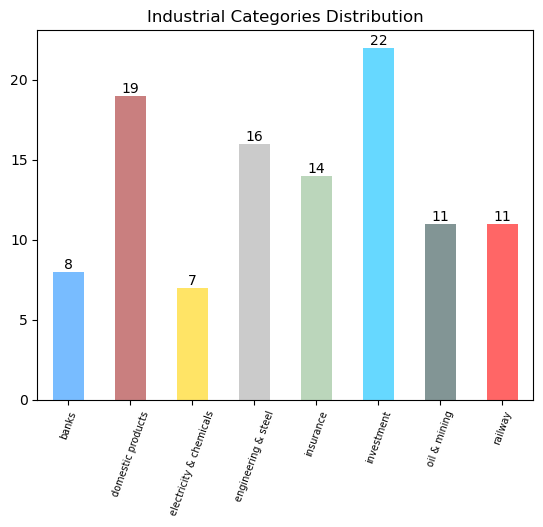

In [90]:
### Categories distribution

colors=df_cl.sort_values('label')['color']

ax=merged_cat.groupby('label').size().plot(kind='bar',
                         color=colors, alpha=0.6)

ax.bar_label(ax.containers[-1])
plt.xticks(size=7, rotation=70)

plt.xlabel('', size=9)
plt.title('Industrial Categories Distribution')

plt.show()

#### Add categories to vertices

In [91]:
### List of nodes' identifiers
nodes = sorted(list(G.nodes.keys()), key=lambda x: int(x))
print(nodes[:3])

['1', '2', '3']


In [92]:
### List of categories in the same order as the nodes
lnc =[(c[1],c[2],c[3]) for c in list(merged_cat.to_records())]
print(lnc[:10])

[(2, 'railway', 'red'), (2, 'railway', 'red'), (2, 'railway', 'red'), (5, 'domestic products', 'brown'), (2, 'railway', 'red'), (2, 'railway', 'red'), (2, 'railway', 'red'), (5, 'domestic products', 'brown'), (5, 'domestic products', 'brown'), (1, 'oil & mining', 'DarkSlateGray')]


In [93]:
### Zip the two lists together
ln = list(zip(nodes,lnc))
print(ln[:10])

[('1', (2, 'railway', 'red')), ('2', (2, 'railway', 'red')), ('3', (2, 'railway', 'red')), ('4', (5, 'domestic products', 'brown')), ('5', (2, 'railway', 'red')), ('6', (2, 'railway', 'red')), ('7', (2, 'railway', 'red')), ('8', (5, 'domestic products', 'brown')), ('9', (5, 'domestic products', 'brown')), ('10', (1, 'oil & mining', 'DarkSlateGray'))]


In [94]:
### Prepare the categories to be added to the nodes
dict_categories = dict([(d[0], {'category_id': d[1][0], 'category_label':d[1][1]}) for d in ln])
print(str(dict_categories)[:100])

{'1': {'category_id': 2, 'category_label': 'railway'}, '2': {'category_id': 2, 'category_label': 'ra


In [95]:
### Add categories  to the nodes
nx.set_node_attributes(G, dict_categories)

pprint.pprint(list(G.nodes.data())[:1])

[('1',
  {'bipartite': 0,
   'category_id': 2,
   'category_label': 'railway',
   'label': 'north british railway'})]


In [24]:
### Inspect categories for companies
print([n[1]['category_id'] for n in list(G.nodes.data()) if int(n[0]) < 109 ][-2:])

### Persons do not have categories
print([n for n in list(G.nodes.data()) if int(n[0]) > 108 ][:2])

[8, 8]
[('109', {'label': 'earl of dalkeith', 'bipartite': 1}), ('110', {'label': 'carlow, c.', 'bipartite': 1})]


#### Create additional labels with categories

In [96]:
### Prepare the industrial category clusters to add to the nodes
add_labels = dict([(n[0], {'add_label':str(n[1]['category_id'])+'/'+ n[0]+'—'+n[1]['label']}) for n in G.nodes.data() if int(n[0]) < 109])

### Add the industrial category clusters to the nodes
nx.set_node_attributes(G, add_labels)


In [98]:
### Inspect nodes
pprint.pprint(list(G.nodes.data())[:2])

[('1',
  {'add_label': '2/1—north british railway',
   'bipartite': 0,
   'category_id': 2,
   'category_label': 'railway',
   'label': 'north british railway'}),
 ('2',
  {'add_label': '2/2—caledonian railway',
   'bipartite': 0,
   'category_id': 2,
   'category_label': 'railway',
   'label': 'caledonian railway'})]


### Add capital to companies

In [99]:
### Open the capital file and zip it together with the 
# nodes' identifiers (they are in the same ordre and samel length)
f='../data/Chapter5/Capital.vec'
vec= pd.read_csv(f)
vec.columns=['capital']
print(vec.head(10))

   capital
0    47236
1    42899
2    14204
3    10000
4     4979
5     4653
6     2325
7     2000
8     1991
9     1850


In [100]:
### Zip capital attibute with notes, in the same order
l = list(vec["capital"])
print(l[:3])
ln = list(zip(nodes,l))
print(ln[:10])

[47236, 42899, 14204]
[('1', 47236), ('2', 42899), ('3', 14204), ('4', 10000), ('5', 4979), ('6', 4653), ('7', 2325), ('8', 2000), ('9', 1991), ('10', 1850)]


count      108.000000
mean      3488.157407
std       7119.652323
min        325.000000
25%        500.000000
50%        824.000000
75%       2081.250000
max      47236.000000
dtype: float64


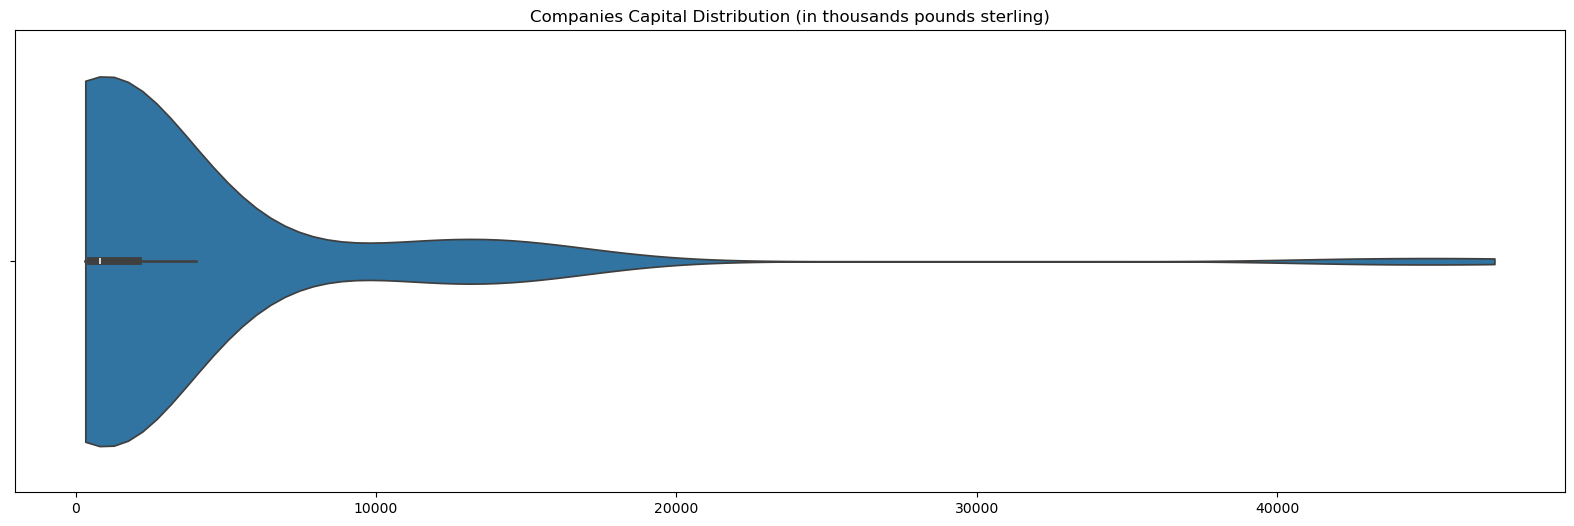

In [101]:
### Capital distribution
naf.describe_violinplot(l, 'Companies Capital Distribution (in thousands pounds sterling)')

In [105]:
### Prepare the capital clusters to add to the nodes
dict_capital = dict([(d[0], {'capital': d[1]}) for d in ln])

### Add the family clusters to the nodes
nx.set_node_attributes(G, dict_capital)

Companies:
[('1',
  {'add_label': '2/1—north british railway',
   'bipartite': 0,
   'capital': 47236,
   'category_id': 2,
   'category_label': 'railway',
   'label': 'north british railway'}),
 ('2',
  {'add_label': '2/2—caledonian railway',
   'bipartite': 0,
   'capital': 42899,
   'category_id': 2,
   'category_label': 'railway',
   'label': 'caledonian railway'})]
Persons:
[('243', {'bipartite': 1, 'label': 'torrie, r.j.'}),
 ('244', {'bipartite': 1, 'label': 'campbell, j.'})]


In [106]:
### Inspect
print('Companies:')
pprint.pprint(list(G.nodes.data())[:2])
print('Persons:')
pprint.pprint(list(G.nodes.data())[-2:])

Companies:
[('1',
  {'add_label': '2/1—north british railway',
   'bipartite': 0,
   'capital': 47236,
   'category_id': 2,
   'category_label': 'railway',
   'label': 'north british railway'}),
 ('2',
  {'add_label': '2/2—caledonian railway',
   'bipartite': 0,
   'capital': 42899,
   'category_id': 2,
   'category_label': 'railway',
   'label': 'caledonian railway'})]
Persons:
[('243', {'bipartite': 1, 'label': 'torrie, r.j.'}),
 ('244', {'bipartite': 1, 'label': 'campbell, j.'})]


### Bipartite graph properties

In [107]:
### Documentation
#  https://networkx.org/documentation/stable/reference/algorithms/bipartite.html
print('Is bipartite: ', bipartite.is_bipartite(G))
print('---')
naf.basic_graph_properties(G)

Is bipartite:  True
---
{'is_multigraph': True,
 'is_directed': False,
 'number_of_nodes': 244,
 'number_of_edges': 358,
 '------': '------',
 'is connected': False,
 'components': 20,
 'density': 0.012075828104972004}


### Graph components


Split and inspect graph components


In [108]:
### Create a list of graphs, one per component
## Connected components
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
try:
    S = [G.subgraph(c).copy() for c in nx.connected_components(G)]

    ### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
    ln = sorted([[i,len(g.nodes)] for i,g in enumerate(S)], key = lambda row: row[1], reverse=True)
    print(ln[:5])

except Exception as e:
    print(e)

[[0, 217], [1, 4], [2, 4], [6, 3], [3, 1]]


In [109]:
### Distribution of components length
s_ln = pd.Series([e[1] for e in ln])
print(s_ln.describe()) 

### Distribution of number of nodes
print('\n\
Distribution of number of nodes:')
l = [print('Nodes in graph: ', e[0],
           ', number of graphs: ', e[1]) for e in s_ln.groupby(by=s_ln).size().items()]



count     20.000000
mean      12.200000
std       48.215088
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      217.000000
dtype: float64

Distribution of number of nodes:
Nodes in graph:  1 , number of graphs:  16
Nodes in graph:  3 , number of graphs:  1
Nodes in graph:  4 , number of graphs:  2
Nodes in graph:  217 , number of graphs:  1


Conclusion: We will only consider the largest component

In [110]:
### Largest graph component
lG = S[0]
naf.basic_graph_properties(lG)

{'is_multigraph': True,
 'is_directed': False,
 'number_of_nodes': 217,
 'number_of_edges': 348,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.014848950332821301}


### Add the degrees

In [111]:
### Identify the two node sets
# https://networkx.org/documentation/stable/reference/algorithms/bipartite.html

companies,persons = bipartite.sets(lG)
print('Companies: ', list(companies)[:3])
print('Persons: ', list(persons)[:3])

Companies:  ['24', '35', '33']
Persons:  ['180', '184', '121']


In [112]:
### Bipartite graph density
# The density is higher because the number of possible 
# relations is lower in a bipartite graph,
# hence a specific algorythm
print(bipartite.density(G, companies))

0.026346776567559613


In [113]:
### Function specific to bipartite networks,
# calculate degrees, then splits nodes
# into two distinct sets

dP,dC = bipartite.degrees(lG,companies)
print('Persons: ', sorted(dP, key=lambda x: int(x[0]))[:3])
print('Companies:', sorted(dC, key=lambda x: int(x[0]))[:3])

Persons:  [('109', 3), ('110', 3), ('111', 5)]
Companies: [('1', 8), ('2', 13), ('3', 5)]


In [114]:
### Same degree values, but just one set
dA = lG.degree()

## Note that this is only the larger graph, 
# some isolated nodes, such as 107, have been dropped
print(sorted(dA, key=lambda x: int(x[0]))[83:90])

[('105', 4), ('106', 1), ('108', 3), ('109', 3), ('110', 3), ('111', 5), ('112', 4)]


In [115]:
### Add the degree to company nodes nodes
# The decree of a company is the number of its directors!
nx.set_node_attributes(lG, dict(dC), 'number_of_directors')
pprint.pprint(list(lG.nodes(data=True))[:2])

[('1',
  {'add_label': '2/1—north british railway',
   'bipartite': 0,
   'capital': 47236,
   'category_id': 2,
   'category_label': 'railway',
   'label': 'north british railway',
   'number_of_directors': 8}),
 ('2',
  {'add_label': '2/2—caledonian railway',
   'bipartite': 0,
   'capital': 42899,
   'category_id': 2,
   'category_label': 'railway',
   'label': 'caledonian railway',
   'number_of_directors': 13})]


In [117]:
### Print network

plt.figure(figsize = (12,12))

node_colors=['blue' if n[1]['bipartite'] == 0 else 'red' for n in lG.nodes.data()]
node_size=[(d[1]-2+0.2)*50+2 for d in lG.degree()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) if n[1]['bipartite'] == 0 else '')) for n in lG.nodes.data()])

#pos = nx.kamada_kawai_layout(U)

k=0.6
pos=nx.spring_layout(lG, k=k)

nx.draw_networkx_nodes(lG, pos, node_size=node_size, node_color=node_colors, alpha=0.4)
nx.draw_networkx_labels(lG, pos, labels=node_labels, font_size=5)

## Edges omitted to improve readability, but
# the structure of the graph is still visible
# nx.draw_networkx_edges(lG, pos,  width=0.5, alpha=0.2)

plt.title('Larger component with both node types (size proportional to nodes degree)')

### cf. SVG picture
plt.savefig('images/bipartite_scotland.svg')
plt.close()

## Treat the multigraph issue

In the import process, the graph was categorizes as multigraph: [MultiGraph—Undirected graphs with self loops and parallel edges](https://networkx.org/documentation/stable/reference/classes/multigraph.html) 

We have to transform it to a simple graph. There is apparently no dedicated function in the Netwokx library to do this transformation.

In [118]:
## Inspect graph properties
naf.basic_graph_properties(lG)
## Inspect edges and their attributes
print(list(lG.edges.data())[-5:])

{'is_multigraph': True,
 'is_directed': False,
 'number_of_nodes': 217,
 'number_of_edges': 348,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.014848950332821301}
[('105', '243', {'weight': 1.0}), ('106', '236', {'weight': 1.0}), ('108', '167', {'weight': 1.0}), ('108', '179', {'weight': 1.0}), ('108', '244', {'weight': 1.0})]


In [119]:
### Print weight distribution
s = pd.Series([e[2]['weight'] for e in lG.edges.data()])
print(s.groupby(by=s).size())

1.0    348
dtype: int64


In [120]:
### Test if multigraph has loops

## Result: no loop

print(list(nx.nodes_with_selfloops(lG)))

[]


#### Treat possible multiple edges

In [121]:
## For each identical edge (same source and target nodes)
# adds 1 to weight. If multiple edges, weight > 1.

## documentation
# https://stackoverflow.com/questions/15590812/networkx-convert-multigraph-into-simple-graph-with-weighted-edges

SG = nx.Graph()
for u,v,data in lG.edges(data=True):
    w = data['weight'] if 'weight' in data else 1.0
    if SG.has_edge(u,v):
        SG[u][v]['weight'] += w
    else:
        SG.add_edge(u, v, weight=w)

print(list(SG.edges(data=True))[:3])

[('1', '109', {'weight': 1.0}), ('1', '110', {'weight': 1.0}), ('1', '111', {'weight': 1.0})]


In [122]:
### List of edges with 'weight' larger than 1
print([e for e in SG.edges.data() if e[2]['weight']> 1])

# No such edge: in fact, the original graph is simple, no loops, no multiple edges

[]


In [123]:
### Print weight distribution
s = pd.Series([e[2]['weight'] for e in SG.edges.data()])
print(s.groupby(by=s).size())

1.0    348
dtype: int64


In [124]:
### Remove the 'weight' attribut from all nodes
attrs_to_remove = ['weight']

for n1, n2, d in lG.edges(data=True):
    for att in attrs_to_remove:
        d.pop(att, None)

l_nd = list(lG.edges.data())
print(l_nd[:5])

[('1', '109', {}), ('1', '110', {}), ('1', '111', {}), ('1', '112', {}), ('1', '113', {})]


In [125]:
### Add attributes of original graph nodes
# to the nodes in the simple graph
nx.set_node_attributes(SG, dict(lG.nodes.data()))
print(list(SG.nodes.data())[:2])

[('1', {'label': 'north british railway', 'bipartite': 0, 'category_id': 2, 'category_label': 'railway', 'add_label': '2/1—north british railway', 'capital': 47236, 'number_of_directors': 8}), ('109', {'label': 'earl of dalkeith', 'bipartite': 1})]


## Project the graph on companies


Graph projection means that a bipartite graph will become unipartite (one-mode): only one kind of nodes will be kept, the other kind will be projected on direct relations betwenn the remaining nodes

A weighted projection counts how many relationships, i.e. nodes inbetween, existed in the original graph and adds the size to the 'weight' attribute.


In [126]:
### First project the graph
## Documentation:
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.bipartite.projection.weighted_projected_graph.html#networkx.algorithms.bipartite.projection.weighted_projected_graph

"""
Parameter 'ratio': Bool (default=False)
If True, edge weight is the ratio between 
actual shared neighbors and maximum possible 
shared neighbors (i.e., the size of the other node set). 
If False, edges weight is the number of shared neighbors.
"""

projSG = bipartite.weighted_projected_graph(SG, companies, ratio=False)

### add weight to list
lwi = dict([((e[0], e[1]), e[2]['weight']) for e in projSG.edges.data()])

### Then reproject the graph but with ratio=True
projSG = bipartite.weighted_projected_graph(SG, companies, ratio=True)

### Then add the integer value
nx.set_edge_attributes(projSG, lwi, 'integer_weight')




pprint.pprint(list(projSG.nodes.data())[:2])
pprint.pprint(list(projSG.edges.data())[:3])

print('---')
naf.basic_graph_properties(projSG)

[('24',
  {'add_label': '5/24—anglo-american direct tea trading',
   'bipartite': 0,
   'capital': 910,
   'category_id': 5,
   'category_label': 'domestic products',
   'label': 'anglo-american direct tea trading',
   'number_of_directors': 8}),
 ('35',
  {'add_label': '3/35—allan line steamships',
   'bipartite': 0,
   'capital': 606,
   'category_id': 3,
   'category_label': 'engineering & steel',
   'label': 'allan line steamships',
   'number_of_directors': 1})]
[('24', '19', {'integer_weight': 8, 'weight': 0.061068702290076333}),
 ('24', '79', {'integer_weight': 1, 'weight': 0.007633587786259542}),
 ('24', '8', {'integer_weight': 8, 'weight': 0.061068702290076333})]
---
{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 86,
 'number_of_edges': 273,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.0746922024623803}


In [127]:
## Remove bipartite attribute
attrs_to_remove = ['bipartite']
naf.remove_node_attributes(projSG, attrs_to_remove)
pprint.pprint(list(projSG.nodes.data())[:1])

[('24',
  {'add_label': '5/24—anglo-american direct tea trading',
   'capital': 910,
   'category_id': 5,
   'category_label': 'domestic products',
   'label': 'anglo-american direct tea trading',
   'number_of_directors': 8})]


count    273.000000
mean       0.010290
std        0.008757
min        0.007634
25%        0.007634
50%        0.007634
75%        0.007634
max        0.061069
dtype: float64


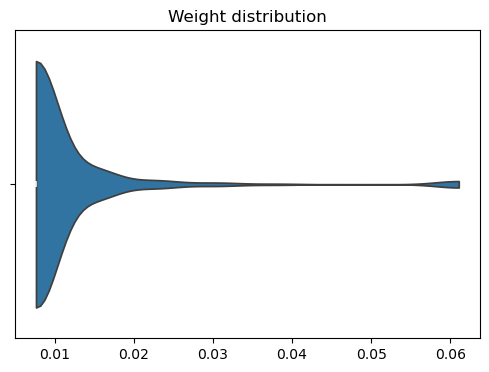

In [134]:
### distribution of normalized weight
lw = [e[2]['weight'] for e in projSG.edges.data()]

naf.describe_violinplot(lw, 'Weight distribution', figsize=(6,4))

count    273.000000
mean       1.347985
std        1.147153
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        8.000000
dtype: float64


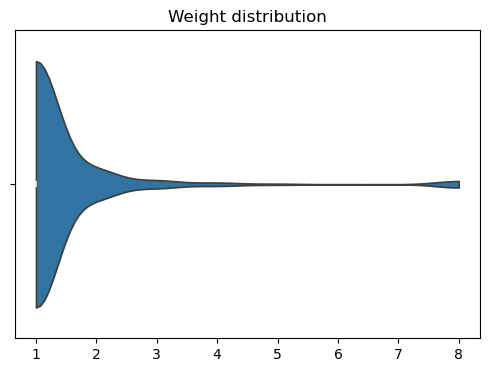

In [133]:
### Distribution of integer weight
lw = [e[2]['integer_weight'] for e in projSG.edges.data()]

naf.describe_violinplot(lw, 'Weight distribution', figsize=(6,4))

count    43.000000
mean      3.209302
std       2.076606
min       2.000000
25%       2.000000
50%       2.000000
75%       3.000000
max       8.000000
dtype: float64


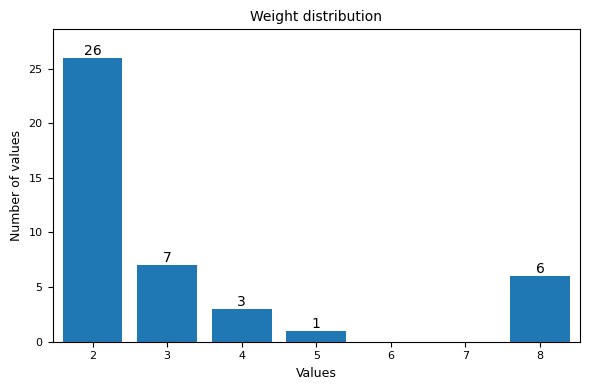

In [138]:
### Distribution of integer weight
lw = [e[2]['integer_weight'] for e in projSG.edges.data() if e[2]['integer_weight'] > 1]

naf.describe_plot_integers_distribution(lw, 'Weight distribution', figsize=(6,4))

### Plot the graph with centralities

#### Eigenvector

count    86.00000000000000000000
mean      0.02694714567761263835
std       0.10502387488932550530
min       0.00000053393592556724
25%       0.00001382393642569029
50%       0.00003751008138064079
75%       0.00020240903541211608
max       0.49350325145174200880
dtype: object


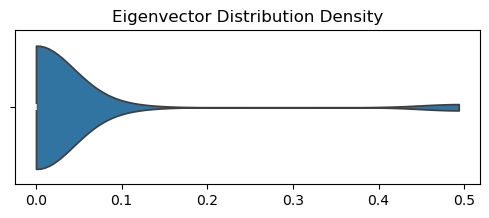

In [139]:
le = list(nx.eigenvector_centrality(projSG, 
                        max_iter=200, weight='weight').items())
### Plot eigenvector density distribution 
eigenvector_s = pd.Series([e[1] for e in le])
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

# Plot the distribution of eigenvector density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=eigenvector_s, orient='h', cut=0)
plt.title('Eigenvector Distribution Density')
plt.show()


In [140]:
nx.set_node_attributes(projSG, dict(le), 'eigenvector')
pprint.pprint(list(projSG.nodes.data())[:1])

[('24',
  {'add_label': '5/24—anglo-american direct tea trading',
   'capital': 910,
   'category_id': 5,
   'category_label': 'domestic products',
   'eigenvector': 0.493503251451742,
   'label': 'anglo-american direct tea trading',
   'number_of_directors': 8})]


count    86.00000000000000000000
mean      0.02694714567761263835
std       0.10502387488932550530
min       0.00000053393592556724
25%       0.00001382393642569029
50%       0.00003751008138064079
75%       0.00020240903541211608
max       0.49350325145174200880
dtype: object


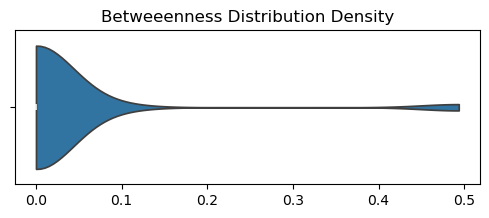

In [141]:
lb = list(nx.betweenness_centrality(G, weight='weight').items())
### Plot betweenness density distribution 
betweenness_s = pd.Series([e[1] for e in le])
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

# Plot the distribution of eigenvector density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=betweenness_s, orient='h', cut=0)
plt.title('Betweeenness Distribution Density')
plt.show()



In [142]:
nx.set_node_attributes(projSG, dict(lb), 'betweenness')
pprint.pprint(list(projSG.nodes.data())[:1])

[('24',
  {'add_label': '5/24—anglo-american direct tea trading',
   'betweenness': 0.013255785404448682,
   'capital': 910,
   'category_id': 5,
   'category_label': 'domestic products',
   'eigenvector': 0.493503251451742,
   'label': 'anglo-american direct tea trading',
   'number_of_directors': 8})]


#### Define normalized degree

In [146]:
### The number of directors is the node degree
# for companies in the bipartite graph, cf. above
lc = sorted(list([(n[0], n[1]['number_of_directors']) for n in projSG.nodes.data()]), key=lambda x: int(x[0]))
print(lc)


[('1', 8), ('2', 13), ('3', 5), ('4', 4), ('6', 6), ('7', 3), ('8', 8), ('9', 2), ('10', 2), ('11', 3), ('12', 1), ('14', 3), ('15', 3), ('16', 3), ('17', 5), ('19', 8), ('20', 1), ('21', 1), ('23', 1), ('24', 8), ('26', 8), ('27', 2), ('28', 4), ('29', 5), ('30', 4), ('31', 1), ('33', 4), ('35', 1), ('36', 1), ('38', 3), ('39', 4), ('45', 3), ('46', 4), ('48', 1), ('50', 1), ('51', 4), ('53', 5), ('55', 2), ('56', 1), ('58', 3), ('59', 3), ('61', 3), ('62', 1), ('63', 1), ('64', 1), ('65', 8), ('66', 9), ('67', 8), ('68', 9), ('69', 10), ('70', 4), ('71', 6), ('73', 12), ('74', 6), ('75', 5), ('76', 9), ('77', 3), ('78', 5), ('79', 2), ('80', 4), ('81', 4), ('82', 5), ('83', 4), ('84', 4), ('85', 5), ('86', 2), ('87', 4), ('88', 4), ('89', 6), ('90', 3), ('91', 3), ('92', 1), ('93', 4), ('94', 1), ('95', 4), ('96', 4), ('98', 1), ('99', 5), ('100', 2), ('101', 3), ('102', 5), ('103', 4), ('104', 4), ('105', 4), ('106', 1), ('108', 3)]


In [147]:
### The degree in the projected graph
# is the number of neighbours companies
ld = sorted(list(projSG.degree()), key=lambda x: int(x[0]))
print(ld)
      

[('1', 14), ('2', 26), ('3', 7), ('4', 11), ('6', 10), ('7', 5), ('8', 7), ('9', 2), ('10', 2), ('11', 7), ('12', 2), ('14', 2), ('15', 8), ('16', 3), ('17', 13), ('19', 7), ('20', 2), ('21', 2), ('23', 3), ('24', 7), ('26', 7), ('27', 8), ('28', 8), ('29', 11), ('30', 10), ('31', 2), ('33', 12), ('35', 2), ('36', 2), ('38', 2), ('39', 3), ('45', 4), ('46', 4), ('48', 4), ('50', 3), ('51', 5), ('53', 14), ('55', 2), ('56', 1), ('58', 10), ('59', 5), ('61', 5), ('62', 1), ('63', 4), ('64', 2), ('65', 10), ('66', 11), ('67', 11), ('68', 9), ('69', 12), ('70', 4), ('71', 17), ('73', 14), ('74', 5), ('75', 6), ('76', 18), ('77', 3), ('78', 5), ('79', 5), ('80', 2), ('81', 5), ('82', 8), ('83', 5), ('84', 6), ('85', 9), ('86', 5), ('87', 6), ('88', 9), ('89', 8), ('90', 6), ('91', 4), ('92', 1), ('93', 6), ('94', 1), ('95', 9), ('96', 8), ('98', 3), ('99', 6), ('100', 5), ('101', 5), ('102', 7), ('103', 6), ('104', 6), ('105', 4), ('106', 1), ('108', 4)]


In [148]:
z = zip(lc,ld)
zz = [(e[0][0],e[0][1], e[1][1]) 
            for e in z]
df_zz = pd.DataFrame(zz, columns=['name', 'n_members', 'degree'] )
#df_zz.set_index('name', inplace=True)
df_zz['norm_degree'] = df_zz.apply(lambda x: x.degree/x.n_members, axis=1)
pprint.pprint(df_zz)

   name  n_members  degree  norm_degree
0     1          8      14     1.750000
1     2         13      26     2.000000
2     3          5       7     1.400000
3     4          4      11     2.750000
4     6          6      10     1.666667
..  ...        ...     ...          ...
81  103          4       6     1.500000
82  104          4       6     1.500000
83  105          4       4     1.000000
84  106          1       1     1.000000
85  108          3       4     1.333333

[86 rows x 4 columns]


count    86.00000000000000000000
mean      1.71411498708010334724
std       0.79663989060802520292
min       0.50000000000000000000
25%       1.00000000000000000000
50%       1.50000000000000000000
75%       2.00000000000000000000
max       4.00000000000000000000
Name: norm_degree, dtype: object


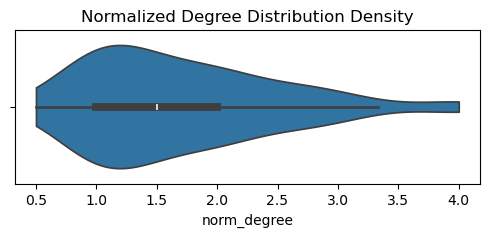

In [149]:
### Plot normalized degree  density distribution 
stats = df_zz.norm_degree.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

# Plot the distribution of eigenvector density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=df_zz.norm_degree, orient='h', cut=0)
plt.title('Normalized Degree Distribution Density')
plt.show()

#### Add to nodes and create dataframe

In [150]:
### Prepare data to add to nodes
ln = dict([(e['name'],
     {'degree':e['degree'], 'norm_degree':e['norm_degree']}
     ) for e in df_zz.to_dict(orient='records')])
# print(str(ln)[:200])


In [151]:
## Add attributes
nx.set_node_attributes(projSG, ln)
pprint.pprint(list(projSG.nodes.data())[:2])

[('24',
  {'add_label': '5/24—anglo-american direct tea trading',
   'betweenness': 0.013255785404448682,
   'capital': 910,
   'category_id': 5,
   'category_label': 'domestic products',
   'degree': 7,
   'eigenvector': 0.493503251451742,
   'label': 'anglo-american direct tea trading',
   'norm_degree': 0.875,
   'number_of_directors': 8}),
 ('35',
  {'add_label': '3/35—allan line steamships',
   'betweenness': 0.0,
   'capital': 606,
   'category_id': 3,
   'category_label': 'engineering & steel',
   'degree': 2,
   'eigenvector': 2.7475099319254007e-05,
   'label': 'allan line steamships',
   'norm_degree': 2.0,
   'number_of_directors': 1})]


### Create dataframe and inspect node properties

We inspect and compare the different properties of the nodes, notably comparing the structural position in the network of the node with its own attributes, like the business category or the capital 


Not the the eigenvector centrality doesn't seem to play a relevant role in this graph.

In [214]:
### Export node attributes to dataframe
nodes_data ={node: projSG.nodes[node] for node in projSG.nodes}
nodes_df = pd.DataFrame(nodes_data).T
nodes_df.reset_index(inplace=True)
nodes_df.columns = ['id', 'label', 'category_id',  'category_label', 'added_label', 'capital',
                    'number_of_directors', 'eigenvector','betweenness',  'degree', 'norm_degree']
nodes_df.head(2)


,id,label,category_id,category_label,added_label,capital,number_of_directors,eigenvector,betweenness,degree,norm_degree
0,24,anglo-american direct tea trading,5,domestic products,5/24—anglo-american direct tea trading,910,8,0.493503,0.013256,7,0.875
1,35,allan line steamships,3,engineering & steel,3/35—allan line steamships,606,1,0.000027,0.0,2,2.0


In [446]:
color_map=dict([(c[0], (c[1], c[2])) for c in cat_list])
pprint.pprint(color_map)

{1: ('oil & mining', 'DarkSlateGray'),
 2: ('railway', 'red'),
 3: ('engineering & steel', 'DarkGrey'),
 4: ('electricity & chemicals', '#FFD300'),
 5: ('domestic products', '#FD7208'),
 6: ('banks', 'DeepSkyBlue'),
 7: ('insurance', 'DarkSeaGreen'),
 8: ('investment', '#63C021')}


In [296]:
### Create a function that plots the comparision among values and properties

def compare_with_scatter_plot(dataframe, value_1, value_2, point_column,point_ratio=1, 
                              c_category='', color_map='', figsize=(12,12), 
                              legend_loc='upper right',title='', n_label =''):

    ### https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html
    # Different colors per class : https://vitalflux.com/python-scatter-plot-different-classes/
    # Legend : https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html
    # Labels : https://stackoverflow.com/questions/14432557/matplotlib-scatter-plot-with-different-text-at-each-data-point



    df=dataframe
    # df_extr=nodes_df[nodes_df.betweenness > 0].sort_values(by='betweenness', ascending=False)

    alpha=0.7

    ### Manage point colors:
    # https://kanoki.org/2020/08/30/matplotlib-scatter-plot-color-by-category-in-python/

    plt.figure(figsize=figsize)


    ### Create lists of colors and labels
    colors = [color_map[category][1] for category in df[c_category]]
    c_labels = [color_map[category][0] for category in df[c_category]]

    unique_labels = list(set(c_labels))
    unique_colors = [color_map[i+1][1] for i in range(len(unique_labels))]


    ax = plt.scatter(df[value_1],
                df[value_2],
            marker='o',
            s = [v*point_ratio for i,v in df[point_column].items()],
            color=colors,        
            alpha=alpha)
    plt.xlabel(value_1.capitalize())
    plt.ylabel(value_2.capitalize())







    if len(n_label)>0:
        for i,row in list(df[[n_label,value_1,value_2]].iterrows()):
            plt.annotate(row[n_label][:20],(row[value_1], row[value_2]), fontsize=6)

    plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', 
                            label=label, markerfacecolor=color, 
                            markersize=8, alpha=alpha
                            ) for label, color in color_map.values()],
                            loc=legend_loc, fontsize=8)
    plt.tight_layout() # rect=[0,0,0.8,1]

    plt.title(title)

    # plt.savefig('plots/revenus_eigenvector_20210526.jpg')
    plt.show()

#### Inspect normalized node degrees

This structural property (based on the ratio between the connections degree and the number of directors) expresses a kind of 'tendency towards connectivity'.

We observe that there are companies with just one or a few directors with several co-directorships: this can of course be interpreted in both directions.

We also observe that engineering/stell, domestic/products and oil/mining tend to have more connectivity despite their limited number of directors.

Finally, we observe that companies with a fairly high capitalisation do not necessarily show a tendency towards connectivity, quite the opposite. In fact the Spearman's rank correlation shows a weak negative trend.



In [317]:
nodes_df.sort_values(by='norm_degree', ascending=False).iloc[:10]

,id,label,category_id,category_label,added_label,capital,number_of_directors,eigenvector,betweenness,degree,norm_degree
26,48,clan line steamers,3,engineering & steel,3/48—clan line steamers,500,1,0.08008,0.0,4,4.0
14,63,victoria jute,5,domestic products,5/63—victoria jute,350,1,0.000041,0.0,4,4.0
6,27,coltness iron,3,engineering & steel,3/27—coltness iron,850,2,0.000092,0.001069,8,4.0
15,58,lothian coal,1,oil & mining,1/58—lothian coal,367,3,0.000083,0.034421,10,3.333333
2,33,irrawaddy flotilla,3,engineering & steel,3/33—irrawaddy flotilla,720,4,0.000341,0.060258,12,3.0
51,50,wemyss collieries trust,1,oil & mining,1/50—wemyss collieries trust,500,1,0.00001,0.0,3,3.0
29,98,oregon mortgage,8,investment,8/98—oregon mortgage,500,1,0.000002,0.0,3,3.0
72,23,west highland railway,2,railway,2/23—west highland railway,929,1,0.00001,0.0,3,3.0
27,71,clydesdale bank,6,banks,6/71—clydesdale bank,10923,6,0.000158,0.048321,17,2.833333
68,53,young's paraffin ligth & mineral oil,4,electricity & chemicals,4/53—young's paraffin ligth & mineral oil,453,5,0.00014,0.036797,14,2.8


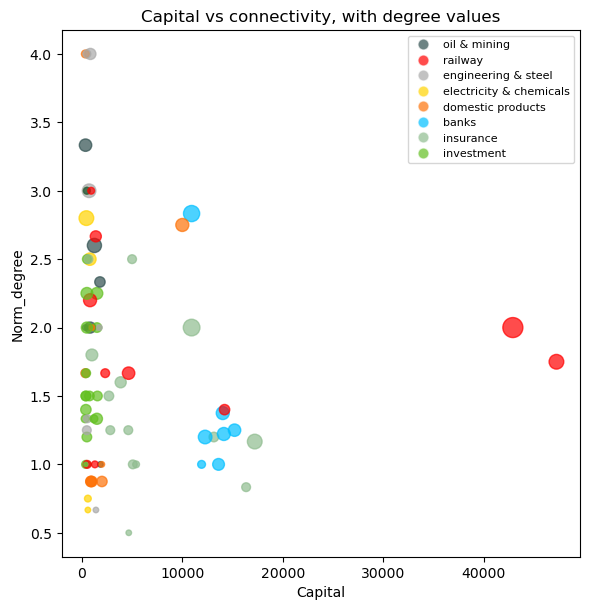

In [326]:
compare_with_scatter_plot(nodes_df, 'capital', 'norm_degree', 'degree', point_ratio=8, c_category='category_id',
                          color_map=color_map, figsize=(6,6), 
                          legend_loc='upper right', 
                          title='Capital vs connectivity, with degree values', n_label='' )

In [331]:
corr_spear = nodes_df[['capital', 'norm_degree']].corr(method="spearman")
print("Spearman's rank correlation: {}".format(corr_spear.iloc[0,1]))

Spearman's rank correlation: -0.16953100584471292


#### Betweennes vs capital

These seem to be the only two parameters that have some kind of correlation with each other.

In [304]:
nodes_df.sort_values(by='betweenness', ascending=False).iloc[:10]

,id,label,category_id,category_label,added_label,capital,number_of_directors,eigenvector,betweenness,degree,norm_degree
79,2,caledonian railway,2,railway,2/2—caledonian railway,42899,13,0.000397,0.166088,26,2.0
77,76,standard life ass.,7,insurance,7/76—standard life ass.,10925,9,0.000117,0.108067,18,2.0
63,73,scottish widows fund life ass.,7,insurance,7/73—scottish widows fund life ass.,17208,12,0.000084,0.107025,14,1.166667
64,6,highland railway,2,railway,2/6—highland railway,4653,6,0.003373,0.08546,10,1.666667
28,28,fife coal,1,oil & mining,1/28—fife coal,831,4,0.003331,0.084795,8,2.0
48,1,north british railway,2,railway,2/1—north british railway,47236,8,0.000196,0.071056,14,1.75
21,67,commercial bank of scotland,6,banks,6/67—commercial bank of scotland,14025,8,0.000352,0.06766,11,1.375
84,68,royal bank of scotland,6,banks,6/68—royal bank of scotland,13606,9,0.000185,0.066173,9,1.0
66,69,union bank of scotland,6,banks,6/69—union bank of scotland,12270,10,0.000035,0.066137,12,1.2
2,33,irrawaddy flotilla,3,engineering & steel,3/33—irrawaddy flotilla,720,4,0.000341,0.060258,12,3.0


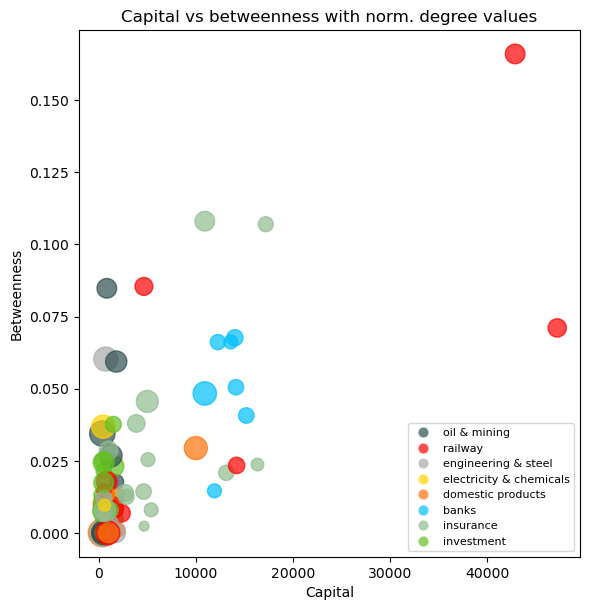

In [325]:
compare_with_scatter_plot(nodes_df, 'capital', 'betweenness', 'norm_degree', point_ratio=100, 
                          c_category='category_id', legend_loc="lower right",
                          color_map=color_map, figsize=(6,6), 
                          title='Capital vs betweenness with norm. degree values' )

In [330]:
corr_spear = nodes_df[['capital', 'betweenness']].corr(method="spearman")
print("Spearman's rank correlation: {}".format(corr_spear.iloc[0,1]))

Spearman's rank correlation: 0.5393768098141057


#### Norm. degree vs betweennes

To have a trend to connection does not bring a company to be more inbetween other nodes 

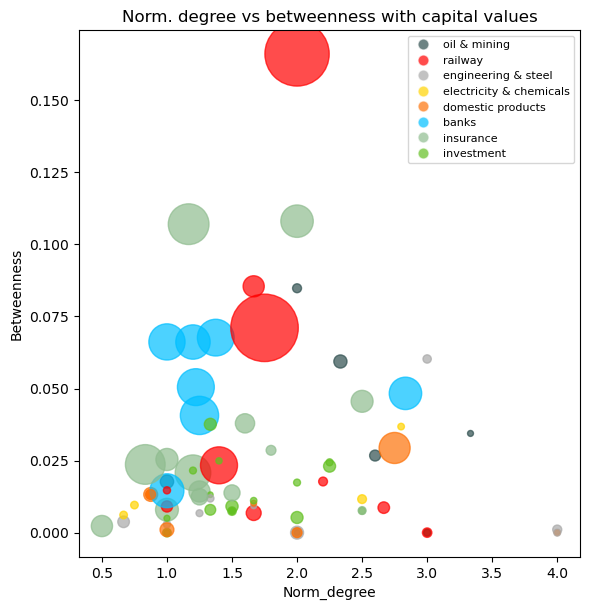

In [327]:
compare_with_scatter_plot(nodes_df, 'norm_degree', 'betweenness', 'capital', point_ratio=0.05, 
                          c_category='category_id', legend_loc="upper right",
                          color_map=color_map, figsize=(6,6), 
                          title='Norm. degree vs betweenness with capital values' )

In [329]:
corr_spear = nodes_df[['norm_degree', 'betweenness']].corr(method="spearman")
print("Spearman's rank correlation: {}".format(corr_spear.iloc[0,1]))

Spearman's rank correlation: 0.0270963303042725


In [ ]:
nodes_df[nodes_df.eigenvector > 0.05].sort_values(by='eigenvector', ascending=False)
# 


## Plot the network of companies

In [ ]:
### Inspect the data
print(list(projSG.nodes.data())[:3])

[('24', {'label': 'anglo-american direct tea trading', 'category_id': 5, 'category_label': 'domestic products', 'add_label': '5/24—anglo-american direct tea trading', 'capital': 910, 'number_of_directors': 8, 'eigenvector': 0.493503251451742, 'betweenness': 0.013255785404448682, 'degree': 7, 'norm_degree': 0.875}), ('35', {'label': 'allan line steamships', 'category_id': 3, 'category_label': 'engineering & steel', 'add_label': '3/35—allan line steamships', 'capital': 606, 'number_of_directors': 1, 'eigenvector': 2.7475099319254007e-05, 'betweenness': 0.0, 'degree': 2, 'norm_degree': 2.0}), ('33', {'label': 'irrawaddy flotilla', 'category_id': 3, 'category_label': 'engineering & steel', 'add_label': '3/33—irrawaddy flotilla', 'capital': 720, 'number_of_directors': 4, 'eigenvector': 0.0003414181754545149, 'betweenness': 0.060257874870586245, 'degree': 12, 'norm_degree': 3.0})]


### Plot of the newtowrk with business categories and capital

In [342]:
### Print network


node_colors= [color_map[n[1]['category_id']][1] for n in projSG.nodes.data()]
node_size= [n[1]['capital']/70 for n in projSG.nodes.data()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in projSG.nodes.data()])

edges_width=[e[2]['weight']*100 for e in projSG.edges.data()]

alpha_n= 0.5


plt.figure(figsize = (12,12))

pos = nx.kamada_kawai_layout(projSG)

k=0.4
#pos=nx.spring_layout(projSG, k=k)

nx.draw_networkx_nodes(projSG, pos, node_size=node_size, node_color=node_colors 
                       , alpha=alpha_n)
nx.draw_networkx_labels(projSG, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(projSG, pos,  width=edges_width, alpha=0.2)

plt.title('Companies (size proportional to capital, color: categories)')

plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', 
                        label=label, markerfacecolor=color, 
                        markersize=8, alpha=alpha_n
                        )
                        for label, color in color_map.values()],
                        loc='lower right', fontsize=8)

### cf. SVG picture
plt.savefig('images/companies_scotland.svg')
plt.close()

### Plot with nodes proportional to capital (width) and betweenness (height)

We observed above a certain trend of correlation.

In [379]:
### Print network

g = projSG

# Create a figure and axis
fig, ax = plt.subplots(figsize=(20,20))

#node_size= [n[1]['capital']/70 for n in g.nodes.data()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in g.nodes.data()])

edges_width=[e[2]['weight']*100 for e in g.edges.data()]

alpha=0.5

pos = nx.kamada_kawai_layout(g)

k=0.4
#pos=nx.spring_layout(g, k=k)

#nx.draw_networkx_nodes(g, pos, node_size=node_size, node_color=node_colors, cmap=plt.get_cmap('Dark2'), alpha=0.4)

# Create the ellipses
for node in g.nodes():
    width = g.nodes[node]['capital']/200000
    height = g.nodes[node]['betweenness']*1.5
    x, y = pos[node]
    degree = g.degree(node)
    color = color_map[g.nodes[node]['category_id']][1]
    ellipse = patches.Ellipse((x, y), width, height, alpha=alpha, facecolor=color)
    ax.add_patch(ellipse)
    
nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(g, pos,  width=edges_width, alpha=0.3)

plt.title('Companies (size proportional to capital and betweenness, color: categories)')

plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', 
                        label=label, markerfacecolor=color, 
                        markersize=8, alpha=alpha_n
                        )
                        for label, color in color_map.values()],
                        loc='lower right', fontsize=8)

### cf. SVG picture
plt.savefig('images/capital_betweenness_companies_scotland.svg')
plt.close()

### Plot with nodes proportional to capital (width) and tendency towards networking (height)

We observed above that companies with a relatively high market capitalisation do not necessarily show a tendency towards networking,and in fact, the Spearman's rank correlation shows a weak negative trend.

In [380]:
### Print network

g = projSG

# Create a figure and axis
fig, ax = plt.subplots(figsize=(20,20))

#node_size= [n[1]['capital']/70 for n in g.nodes.data()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in g.nodes.data()])

edges_width=[e[2]['weight']*100 for e in g.edges.data()]

alpha=0.5

pos = nx.kamada_kawai_layout(g)

k=0.4
#pos=nx.spring_layout(g, k=k)

#nx.draw_networkx_nodes(g, pos, node_size=node_size, node_color=node_colors, cmap=plt.get_cmap('Dark2'), alpha=0.4)

# Create the ellipses
for node in g.nodes():
    width = g.nodes[node]['capital']/180000
    height = g.nodes[node]['norm_degree']/10
    x, y = pos[node]
    degree = g.degree(node)
    color = color_map[g.nodes[node]['category_id']][1]
    ellipse = patches.Ellipse((x, y), width, height, alpha=alpha, facecolor=color)
    ax.add_patch(ellipse)
    
nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(g, pos,  width=edges_width, alpha=0.3)

plt.title('Companies (size proportional to capital and betweenness, color: categories)')

plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', 
                        label=label, markerfacecolor=color, 
                        markersize=8, alpha=alpha_n
                        )
                        for label, color in color_map.values()],
                        loc='lower right', fontsize=8)

### cf. SVG picture
plt.savefig('images/capital_normDegree_companies_scotland.svg')
plt.close()

## m-slices and communities

### m-slices

We can experiment with different filters on edges weight, on the lower or the higher part of the distribution

count    273.000000
mean       1.347985
std        1.147153
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        8.000000
dtype: float64


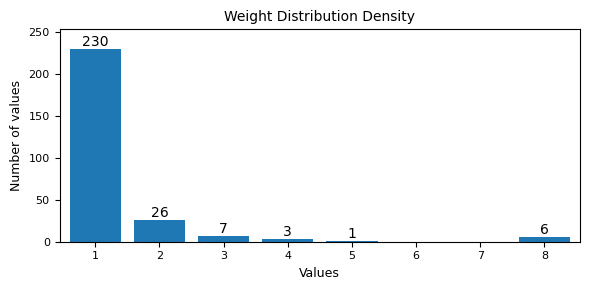

In [372]:
lw = [e[2]['integer_weight'] for e in projSG.edges.data()]
#print(lw[:3])
naf.describe_plot_integers_distribution(lw, 'Weight Distribution Density', figsize=(6,3))

In [ ]:
### Weight more than 1 
# Also try with less than 5, 4 or 3 : no significant changes,
# given the distribution and graph structure 
edges_list = [(e[0], e[1]) for e in projSG.edges.data() if e[2]['integer_weight'] > 1]
print(edges_list[:2])
sub_pG = projSG.edge_subgraph(edges_list).copy()
naf.basic_graph_properties(sub_pG)

[('24', '19'), ('24', '8')]
{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 45,
 'number_of_edges': 43,
 '------': '------',
 'is connected': False,
 'components': 10,
 'density': 0.043434343434343436}


In [ ]:
### Print network

g = sub_pG


# Create a figure and axis
fig, ax = plt.subplots(figsize=(15,15))


node_colors= [color_map[n[1]['category_id']][1] for n in projSG.nodes.data()]
node_size= [n[1]['capital']/70 for n in g.nodes.data()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in g.nodes.data()])

edges_width=[e[2]['weight']*15 for e in g.edges.data()]

#pos = nx.kamada_kawai_layout(g)

k=0.07
pos=nx.spring_layout(g, k=k, )

#nx.draw_networkx_nodes(g, pos, node_size=node_size, node_color=node_colors, cmap=plt.get_cmap('Dark2'), alpha=0.4)

# Create the ellipses
for node in g.nodes():
    width = g.nodes[node]['capital']/200000
    height = g.nodes[node]['norm_degree']/30
    x, y = pos[node]
    degree = g.degree(node)
    color = color_map[g.nodes[node]['category_id']][1]
    ellipse = patches.Ellipse((x, y), width, height, alpha=0.5, facecolor=color)
    ax.add_patch(ellipse)
    
nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(g, pos,  width=edges_width, alpha=0.3)

plt.title('m-slice companies with edge-weight > 1 (size proportional to capital and normalized degree, color: categories)')

plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', 
                        label=label, markerfacecolor=color, 
                        markersize=8, alpha=alpha_n
                        )
                        for label, color in color_map.values()],
                        loc='lower right', fontsize=8)

### cf. SVG picture
plt.savefig('images/m-sliced_companies_scotland.svg')
plt.close()

In [ ]:
nodes_df[nodes_df.norm_degree > 2]\
   .sort_values(by='betweenness', ascending=False)

### Louvain Method modularity detection

Documentation: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html

In [419]:
l_communities = list(nx.community.louvain_communities(projSG))
print( len(l_communities), l_communities)

6 [{'90', '87', '55', '74', '77', '61', '89', '28', '85', '67', '59', '95', '21', '84', '98', '106', '102', '81', '91', '31', '68', '92', '82', '108', '78', '66'}, {'65', '96', '105', '73', '88', '99', '70', '100', '101', '75'}, {'29', '15', '30', '62', '94', '35', '20', '33', '76', '4', '45', '46', '53', '2', '58', '51', '17', '27', '71', '38', '9', '56', '39'}, {'69', '3', '12', '80', '83'}, {'19', '24', '79', '26', '8', '36', '11', '86', '48', '64', '10'}, {'50', '1', '6', '103', '104', '23', '14', '16', '93', '63', '7'}]


In [ ]:
# Create a dictionary to map community IDs to colors
colors = ['red',  'blue', 'yellow','brown', 'grey', 'green']
color_map_communitites = {i: colors[i % len(colors)] for i in range(len(l_communities))}

# Create a dictionary to map nodes to community IDs
node_colors = {}
for i, community in enumerate(l_communities):
    for node in community:
        node_colors[node] = color_map_communitites[i]

In [425]:
print(list(node_colors.items())[:3])

[('90', 'red'), ('87', 'red'), ('55', 'red')]


In [426]:
print(list(l_communities[3]))

['69', '3', '12', '80', '83']


In [427]:
### Print network


node_colors= [e[1] for e in list(node_colors.items())]
node_size= [n[1]['capital']/70 for n in projSG.nodes.data()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in projSG.nodes.data()])

edges_width=[e[2]['weight']*100 for e in projSG.edges.data()]

plt.figure(figsize = (12,12))

pos = nx.kamada_kawai_layout(projSG)

k=0.4
#pos=nx.spring_layout(projSG, k=k)

## , cmap=plt.get_cmap('Dark2')
nx.draw_networkx_nodes(projSG, pos, node_size=node_size, node_color=node_colors, alpha=0.4)
nx.draw_networkx_labels(projSG, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(projSG, pos,  width=edges_width, alpha=0.2)

plt.title('Clustered Companies (size proportional to capital, color: communities)')

### cf. SVG picture
plt.savefig('images/communitites_companies_scotland.svg')
plt.close()

#### Inspect communities

Change the index value in the communities list

In [428]:
nodes_df[nodes_df.id.isin(l_communities[3]) ]\
   .sort_values(by='capital', ascending=False)

,id,label,category_id,category_label,added_label,capital,number_of_directors,eigenvector,betweenness,degree,norm_degree
45,3,glasgow & south western railway,2,railway,2/3—glasgow & south western railway,14204,5,0.000024,0.023356,7,1.4
66,69,union bank of scotland,6,banks,6/69—union bank of scotland,12270,10,0.000035,0.066137,12,1.2
60,80,scottish amicable life ass.,7,insurance,7/80—scottish amicable life ass.,4670,4,0.000007,0.002292,2,0.5
76,83,city of glasgow life ass.,7,insurance,7/83—city of glasgow life ass.,2832,4,0.000016,0.012467,5,1.25
71,12,north british locomotive,3,engineering & steel,3/12—north british locomotive,1750,1,0.000004,0.0,2,2.0


#### Create a graph with split Louvain algorythn communities


We use again the colors for the business types

In [430]:
### Create a list of graphs, one per component
## Connected components
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
try:
    commS = [projSG.subgraph(list(c)).copy() for c in l_communities]

    print(len(commS))

    ### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
    ln = sorted([[i,len(g.nodes)] for i,g in enumerate(commS)], key = lambda row: row[1], reverse=True)
    print(ln[:5])


except Exception as e:
    print(e)


6
[[0, 26], [2, 23], [4, 11], [5, 11], [1, 10]]


In [431]:
s_ln = pd.Series([e[1] for e in ln])
print(s_ln.describe()) 

### Distribution of number of nodes
print('\n\
Distribution of number of nodes:')
l = [print('Nodes in graph: ', e[0],
           ', number of graphs: ', e[1]) for e in s_ln.groupby(by=s_ln).size().items()]



count     6.000000
mean     14.333333
std       8.238123
min       5.000000
25%      10.250000
50%      11.000000
75%      20.000000
max      26.000000
dtype: float64

Distribution of number of nodes:
Nodes in graph:  5 , number of graphs:  1
Nodes in graph:  10 , number of graphs:  1
Nodes in graph:  11 , number of graphs:  2
Nodes in graph:  23 , number of graphs:  1
Nodes in graph:  26 , number of graphs:  1


In [432]:
li = range(0, len(commS))
pG = nx.Graph()
for i in li:
    ## ajoute au graphe les composantes en utilisant
    # l'index ou position dans la liste de graphes 'S'
    pG = nx.union(pG, commS[i])
naf.basic_graph_properties(pG)

{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 86,
 'number_of_edges': 199,
 '------': '------',
 'is connected': False,
 'components': 6,
 'density': 0.05444596443228454}


In [444]:
pprint.pprint(cat_list)

[(1, 'oil & mining', 'DarkSlateGray'),
 (2, 'railway', 'red'),
 (3, 'engineering & steel', 'DarkGrey'),
 (4, 'electricity & chemicals', '#FFD300'),
 (5, 'domestic products', '#FD7208'),
 (6, 'banks', 'DeepSkyBlue'),
 (7, 'insurance', 'DarkSeaGreen'),
 (8, 'investment', '#63C021')]


In [ ]:
pprint.pprint([n[1]['category_id'] for n in pG.nodes.data()])

In [476]:
### Print network

g = pG


# Create a figure and axis
fig, ax = plt.subplots(figsize=(25,25))


node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in g.nodes.data()])

edges_width=[e[2]['weight']*100 for e in g.edges.data()]


#pos = nx.kamada_kawai_layout(g)

k=0.3
pos=nx.spring_layout(g, k=k, scale=3, weight=0.5)

#nx.draw_networkx_nodes(g, pos, node_size=node_size, node_color=node_colors, cmap=plt.get_cmap('Dark2'), alpha=0.4)

# Create the ellipses
for node in g.nodes():
    width = g.nodes[node]['capital']/180000
    height = g.nodes[node]['norm_degree']/30
    x, y = pos[node]
    color = color_map[g.nodes[node]['category_id']][1]
    ellipse = patches.Ellipse((x, y), width, height, alpha=0.5, facecolor=color)
    ax.add_patch(ellipse)
    
nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(g, pos,  width=edges_width, alpha=0.3)

plt.title('Separated Louvain Communitites (size proportional to capital and normalized degree, color: categories)')
    
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', 
                        label=label, markerfacecolor=color, 
                        markersize=8, alpha=alpha_n
                        )
                        for label, color in color_map.values()],
                        loc='lower right', fontsize=8)


### cf. SVG picture
plt.savefig('images/separated_communities_companies_scotland.svg')
plt.close()